# 04 — PLS Selection and Stability

**Thesis:** *Nowcasting and Indicator Selection in a Data-Rich Environment: An Application to German GDP Growth*

## Purpose

This notebook adds the PLS+VIP selector and compares it with the elastic net, the fixed-*k* path and a frequency-smoothed EN matrix. PLS is a Part I signal in its own right. Frequency smoothing and the ≥3/4 vote set are diagnostics; the vote set is later used to tune XGBoost. Part II feeds the DFM the elastic-net, block-balanced and PLS sets, plus a frozen ifoCAST reference — not a single consensus list.

## Contents

| Section | Description |
|---|---|
| 1. Load selection matrices | Load Elastic Net and fixed-*k* (Bai & Ng, 2008) selection results from notebook 03 |
| 2. PLS + VIP selection | Supervised dimension reduction using Partial Least Squares and Variable Importance in Projection |
| 3. Frequency smoothing | Temporal post-processing of EN selections to reduce vintage-to-vintage instability |
| 4. Cross-method comparison | Quantitative assessment of selection stability and pairwise method agreement |
| 4b. Interpretation | Category mix, persistence, and the size of the ≥3/4 vote set |
| 4c. Diagnostic guide | Reading notes for figures and tables |

## Methodological Rationale

### Partial Least Squares (PLS) + Variable Importance in Projection (VIP)

**Economic motivation:** In macroeconomic nowcasting, we seek predictors that carry unique information about the target (German GDP growth), not merely the largest variance contributors as in PCA-based methods. PLS constructs latent components by maximising *covariance* with the target rather than explained variance in the predictor space (Wold, 1966; Geladi & Kowalski, 1986). This supervised projection is particularly valuable when the predictor set exhibits high collinearity — a defining feature of macroeconomic panels where multiple series measure related economic phenomena (Kelly & Pruitt, 2015).

**Statistical properties:** VIP scores quantify each predictor's contribution to the PLS model, accounting for both the weight magnitude and the explained variance of each component (Mehmood et al., 2012; Chong & Jun, 2005). Variables with VIP > 1 are conventionally considered "important," though we rank and select the top *k* to maintain a manageable input dimension for the subsequent DFM stage.

**Comparison to Elastic Net:** While EN penalises coefficients to enforce sparsity (Zou & Hastie, 2005), PLS-VIP identifies importance through supervised covariance structure. The two methods can produce complementary predictor sets: EN tends to pick one representative from highly correlated groups, whereas PLS-VIP may retain multiple series if they jointly improve target prediction.

**Reference:** Kelly, B. T., & Pruitt, S. (2015). The three-pass regression filter: A new approach to forecasting using many predictors. *Journal of Econometrics*, 186(2), 294–316.

### Frequency Smoothing

**Problem statement:** Point-in-time Elastic Net selections can exhibit substantial month-to-month variation ("jumpiness") due to marginal changes in the predictor panel, cross-validation noise, or small shifts in predictor correlations (Bai & Ng, 2008; De Mol et al., 2008). For the DFM, a more stable active set across adjacent vintages facilitates consistent factor extraction and reduces estimation noise.

**Method:** For each forecast origin, we compute a backwards-looking selection frequency by averaging the binary EN selections over all monthly vintages whose training window terminates within the most recent `window_quarters` distinct end-quarters (default: 2 quarters ≈ 6 pooled monthly origins). A series is retained if its mean selection frequency ≥ `min_freq` (default: 0.5). This is a *persistence filter* over pooled history, not a subset operation on the current-period selection.

**Key property:** Because the smoothed value aggregates across multiple rows, the smoothed selection count per origin can increase or decrease relative to the raw EN count. A series absent from the current raw selection may be included if it appears frequently in the recent window; conversely, a currently selected series may be dropped if it lacks historical persistence.

**Design choice — two-quarter window:** Reducing the smoothing window from 4 to 2 quarters balances noise suppression with responsiveness to structural breaks. Macroeconomic data are subject to regime changes (e.g., pandemic onset in 2020Q2, energy-price shock in 2022Q3) where the relevant predictor set can shift within quarters. A shorter window allows the model to adapt within 1–2 quarters while still filtering high-frequency month-to-month noise (Lenza & Primiceri, 2022).

**References:**
- Bai, J., & Ng, S. (2008). Forecasting economic time series using targeted predictors. *Journal of Econometrics*, 146(2), 304–317.
- De Mol, C., Giannone, D., & Reichlin, L. (2008). Forecasting using a large number of predictors: Is Bayesian shrinkage a valid alternative to principal components? *Journal of Econometrics*, 146(2), 318–328.
- Lenza, M., & Primiceri, G. E. (2022). How to estimate a VAR after March 2020. *Journal of Applied Econometrics*, 37(4), 688–699.


In [ ]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Portable repository setup ---
_repo = next(
    (base for base in (Path.cwd(), *Path.cwd().parents)
     if (base / "src" / "german_gdp_nowcasting").is_dir()),
    None,
)
if _repo is None:
    raise RuntimeError("Could not locate src/german_gdp_nowcasting.")
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from german_gdp_nowcasting.config import paths as _tp
from german_gdp_nowcasting.selection.core_utils import (
    DEFAULT_ALPHAS,
    DEFAULT_L1_RATIOS,
    build_coverage_mask,
    load_monthly_panel,
    load_trafo_map,
    make_monthly_forecast_origins,
)
from german_gdp_nowcasting.selection.pls_selection import run_expanding_selection_pls
from german_gdp_nowcasting.selection.selection_postprocessing import (
    apply_frequency_smoothing,
    compute_selection_stability,
)

OUT_DIR = _tp.OUT_INDICATOR_SELECTION
OUT_DIR.mkdir(parents=True, exist_ok=True)
FORECAST_START = '2011-01'
FORECAST_END = '2025-12'
MIN_COVERAGE = 0.30
# PLS hyper-parameters
PLS_N_COMPONENTS = 5
PLS_TOP_K = 30
IMPUTER_STRATEGY = "iterative"  # "mean" (default, fast) | "iterative" (opt-in)
# Frequency-smoothing parameters
# window_quarters=2 (~6 pooled monthly origins, half year): agile enough to
# react to structural breaks within 1–2 quarters while filtering month-noise.
SMOOTH_WINDOW_QUARTERS = 2
SMOOTH_MIN_FREQ = 0.5  # mean raw selection over pooled monthly rows in window ≥ this
RUN_PLS = True   # set False to load a previously saved PLS matrix
PLS_MATRIX_PATH = OUT_DIR / 'selection_matrix_pls.csv'
PLS_RESULTS_PATH = OUT_DIR / 'selection_results_pls.json'
SMOOTH_MATRIX_PATH = OUT_DIR / 'selection_matrix_en_smoothed.csv'


## 1. Load Selection Matrices from Notebook 03

This section imports the baseline selection outputs produced by the Elastic Net (with cross-validated regularisation) and the fixed-*k* = 30 Bai–Ng (2008) benchmark from `03_elastic_net_selection.ipynb`. These matrices form the starting point for the PLS and frequency-smoothing extensions implemented below.

**Required inputs:**
- `selection_matrix.csv`: Binary (180 origins × 585 series) Elastic Net selections
- `selection_matrix_fixedk.csv`: Binary fixed-*k* selections
- `selection_results.json`: Per-origin metadata (training window, selected hyperparameters, CV error)

**Real-time structure:** All four methods respect the expanding-window design: at each monthly forecast origin, only data available up to that origin's information cutoff are used for selection. This ensures comparability and prevents look-ahead bias in the cross-method analysis.

In [6]:
for p in [_tp.SELECTION_MATRIX_CSV, _tp.FIXEDK_MATRIX_CSV]:
    if not p.exists():
        raise FileNotFoundError(
            f'Required file not found: {p}\n'
            'Run 03_elastic_net_selection.ipynb with RUN_FULL_SELECTION=True and RUN_FIXEDK=True first.'
        )
en_matrix = pd.read_csv(_tp.SELECTION_MATRIX_CSV, index_col='forecast_origin')
fixedk_matrix = pd.read_csv(_tp.FIXEDK_MATRIX_CSV, index_col='forecast_origin')
with open(_tp.SELECTION_RESULTS_JSON) as f:
    en_results = json.load(f)
print(f'EN matrix      : {en_matrix.shape[0]} origins × {en_matrix.shape[1]} series')
print(f'block-balanced (k=20) matrix : {fixedk_matrix.shape[0]} origins × {fixedk_matrix.shape[1]} series')
print(f'\nOrigin range   : {en_matrix.index[0]} → {en_matrix.index[-1]}')

EN matrix      : 180 origins × 585 series
Fixed-k matrix : 180 origins × 585 series

Origin range   : 2011-01 → 2025-12


## 2. Partial Least Squares (PLS) + Variable Importance in Projection (VIP) Selection

### Background and Economic Rationale

In high-dimensional nowcasting, predictor selection faces two challenges: (i) strong multicollinearity among macroeconomic indicators measuring related economic concepts (e.g., multiple industrial production indices, survey indicators), and (ii) the need to identify variables that predict the *target* (GDP growth), not merely those with large variance (Stock & Watson, 2002).

**PLS addresses both:**
1. **Supervised dimension reduction:** PLS components maximise the covariance between predictors **X** and target **y**, directing the projection toward dimensions relevant for forecasting rather than variance maximisation as in PCA (Wold, 1966; Geladi & Kowalski, 1986).

2. **Multicollinearity robustness:** Unlike Lasso/Elastic Net, which arbitrarily selects one variable from a correlated group, PLS can assign positive importance to multiple correlated predictors if they jointly contribute to target prediction (Zou & Hastie, 2005; Kelly & Pruitt, 2015).

3. **VIP importance ranking:** After fitting a PLS model with *m* components, the Variable Importance in Projection (VIP) score aggregates each predictor's loading across all components, weighted by the variance explained by each component (Chong & Jun, 2005; Mehmood et al., 2012). Variables with VIP > 1 are conventionally above-average contributors; we rank all series and select the top-*k*.

### Implementation

The expanding-window PLS procedure mirrors the Elastic Net setup from notebook 03:
- **Monthly origins:** 2011-01 through 2025-12 (180 points)
- **Training frequency:** Refit quarterly (training data change at quarter boundaries)
- **Hyperparameters:** `n_components = 5` (extracting 5 PLS latent factors), `top_k = 30` (select 30 highest-VIP series per origin)
- **Coverage filter:** Same 30% minimum-coverage mask applied to EN
- **Imputation:** Iterative imputer (MICE-style) to handle the ragged-edge panel before PLS fitting

### Economic Interpretation

On this panel PLS is the extreme hard-data selector: 99.6–100% of its mass is production, turnover, orders, trade and construction, with survey mass indistinguishable from zero. That is a different mix from the elastic net (which still keeps a survey minority), not a rotation towards confidence indices.

**References:**
- Chong, I. G., & Jun, C. H. (2005). Performance of some variable selection methods when multicollinearity is present. *Chemometrics and Intelligent Laboratory Systems*, 78(1–2), 103–112.
- Geladi, P., & Kowalski, B. R. (1986). Partial least-squares regression: A tutorial. *Analytica Chimica Acta*, 185, 1–17.
- Kelly, B. T., & Pruitt, S. (2015). The three-pass regression filter: A new approach to forecasting using many predictors. *Journal of Econometrics*, 186(2), 294–316.
- Mehmood, T., Liland, K. H., Snipen, L., & Sæbø, S. (2012). A review of variable selection methods in partial least squares regression. *Chemometrics and Intelligent Laboratory Systems*, 118, 62–69.
- Stock, J. H., & Watson, M. W. (2002). Forecasting using principal components from a large number of predictors. *Journal of the American Statistical Association*, 97(460), 1167–1179.
- Wold, H. (1966). Estimation of principal components and related models by iterative least squares. In P. R. Krishnaiah (Ed.), *Multivariate Analysis* (pp. 391–420). Academic Press.
- Zou, H., & Hastie, T. (2005). Regularization and variable selection via the elastic net. *Journal of the Royal Statistical Society: Series B*, 67(2), 301–320.


In [7]:
X_monthly = load_monthly_panel(_tp.PANEL_TRANSFORMED_CSV)
trafo_map = load_trafo_map(_tp.DATA_DICT_ENRICHED_CSV)
forecast_origins = make_monthly_forecast_origins(FORECAST_START, FORECAST_END)
coverage_mask = build_coverage_mask(
    X_monthly, forecast_origins, min_coverage=MIN_COVERAGE
)
_gdp_raw = pd.read_csv(_tp.GDP_TARGET_CSV, index_col='quarter').iloc[:, 0]
y_quarterly = _gdp_raw.set_axis(pd.PeriodIndex(_gdp_raw.index, freq='Q'))
def _pls_outputs_available() -> bool:
    """True if matrix and results exist and results JSON is valid."""
    if not (PLS_MATRIX_PATH.exists() and PLS_RESULTS_PATH.exists()):
        return False
    try:
        with PLS_RESULTS_PATH.open() as f:
            json.load(f)
    except json.JSONDecodeError:
        print(f'Corrupt JSON at {PLS_RESULTS_PATH}; will rerun PLS selection.')
        return False
    return True
# Only rerun PLS if result files do not exist (or JSON is corrupt)
if not _pls_outputs_available():
    print(f'Running PLS+VIP: n_components={PLS_N_COMPONENTS}, top_k={PLS_TOP_K} ...')
    pls_matrix, pls_results = run_expanding_selection_pls(
        X_monthly=X_monthly,
        y_quarterly=y_quarterly,
        trafo_map=trafo_map,
        forecast_origins=forecast_origins,
        coverage_mask=coverage_mask,
        train_start_quarter='1991Q1',
        n_components=PLS_N_COMPONENTS,
        top_k=PLS_TOP_K,
        imputer_strategy=IMPUTER_STRATEGY,
    )
    pls_matrix.to_csv(PLS_MATRIX_PATH)
    with PLS_RESULTS_PATH.open('w') as f:
        json.dump(pls_results, f, indent=2)
    print(f'PLS matrix saved → {PLS_MATRIX_PATH}')
else:
    pls_matrix = pd.read_csv(PLS_MATRIX_PATH, index_col='forecast_origin')
    with open(PLS_RESULTS_PATH) as f:
        pls_results = json.load(f)
    print(f'Loaded existing PLS matrix: {pls_matrix.shape}')
n_pls = pls_matrix.sum(axis=1)
print(f'\nPLS selected per origin — mean: {n_pls.mean():.1f}  '
      f'min: {n_pls.min()}  max: {n_pls.max()}')


Loaded existing PLS matrix: (180, 585)

PLS selected per origin — mean: 30.0  min: 30  max: 30


## 3. Frequency Smoothing Applied to the Elastic Net Matrix

### Motivation: Reducing Selection Instability

Elastic Net selections at the monthly forecast origin level can exhibit substantial temporal variation due to:
1. **Cross-validation noise:** Small changes in fold composition or predictor correlations can shift the optimal regularisation path (Hastie et al., 2009).
2. **Panel evolution:** The addition or revision of series in real-time vintages introduces marginal changes in the covariance structure.
3. **Structural breaks:** Sudden shifts in GDP dynamics (e.g., pandemic, policy regime changes) can cause abrupt reordering of predictor relevance.

For the Dynamic Factor Model in Part II, a more temporally stable predictor set offers two advantages: (i) consistent factor space across adjacent vintages, facilitating interpretation of factor dynamics; (ii) reduced estimation noise from factors driven by transiently selected series (Bai & Ng, 2008; Boivin & Ng, 2006).

### Method: Backwards-Looking Persistence Filter

**Algorithm:**  
For each monthly forecast origin *t*:
1. Identify all monthly origins in the selection matrix whose training window terminates within the most recent `window_quarters` distinct end-quarters relative to *t* (default: 2 quarters).
2. This creates a pool of approximately 6 monthly rows (2 quarters × 3 months/quarter), though the exact count varies depending on the training-end-quarter calendar.
3. For each series *j*, compute the mean of its binary selection indicator (0 or 1) across the pooled rows.
4. Retain series *j* in the smoothed selection for origin *t* if and only if this mean ≥ `min_freq` (default: 0.5).

**Temporal safety:** The procedure is strictly backwards-looking and uses only selections from origins with information cutoffs no later than *t*. No look-ahead bias is introduced.

### Key Properties

**Non-monotonic count changes:**  
Unlike a simple "remove unstable series" operation, frequency smoothing is an *independent filtering step* over pooled history. Consequently:
- A series **absent** from the raw EN selection at origin *t* may appear in the smoothed selection if it was selected frequently in the recent window.
- A series **present** in the raw EN selection at *t* may be **dropped** in the smoothed version if it lacks historical persistence.
- The total number of selected series per origin can **increase** or **decrease** relative to raw EN. An observed increase (negative "reduction") indicates that persistent-but-intermittently-absent series outnumber currently-selected-but-historically-rare series.

**Choice of 2-quarter window:**  
A longer window (e.g., 4 quarters) provides stronger noise suppression but delays the model's ability to incorporate predictors that become relevant during regime shifts. Macroeconomic forecasting often faces abrupt structural breaks (CEPR business-cycle dates, policy interventions) where the relevant predictor set changes within 1–2 quarters (Lenza & Primiceri, 2022; Castle et al., 2015). The 2-quarter window balances responsiveness with stability: approximately 6 pooled origins provide sufficient signal to identify persistent indicators while allowing adaptation within a half-year.

**References:**
- Bai, J., & Ng, S. (2008). Forecasting economic time series using targeted predictors. *Journal of Econometrics*, 146(2), 304–317.
- Boivin, J., & Ng, S. (2006). Are more data always better for factor analysis? *Journal of Econometrics*, 132(1), 169–194.
- Castle, J. L., Doornik, J. A., & Hendry, D. F. (2015). Model selection when there are multiple breaks. *Journal of Econometrics*, 169(2), 239–246.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
- Lenza, M., & Primiceri, G. E. (2022). How to estimate a VAR after March 2020. *Journal of Applied Econometrics*, 37(4), 688–699.


In [ ]:
en_smoothed = apply_frequency_smoothing(
    en_matrix,
    window_quarters=SMOOTH_WINDOW_QUARTERS,
    min_freq=SMOOTH_MIN_FREQ,
)
en_smoothed.to_csv(SMOOTH_MATRIX_PATH)
print(f'Smoothed EN matrix saved → {SMOOTH_MATRIX_PATH}')
n_en_raw    = en_matrix.sum(axis=1)
n_en_smooth = en_smoothed.sum(axis=1)
print(f'\nRaw EN      — mean: {n_en_raw.mean():.1f}  '
      f'min: {n_en_raw.min()}  max: {n_en_raw.max()}')
print(f'Smoothed EN — mean: {n_en_smooth.mean():.1f}  '
      f'min: {n_en_smooth.min()}  max: {n_en_smooth.max()}')
print(f'\nAvg reduction in selected count: {(n_en_raw - n_en_smooth).mean():.1f} per origin')


## 4. Cross-Method Comparison

### Purpose

This section quantifies the agreement and divergence among four indicator selection strategies to assess (i) the **stability** of each method's choices across vintages, and (ii) the **overlap** (Jaccard similarity) between methods. The thesis result is weak series-level agreement: Spearman rank correlations among the data-driven methods are 0.28–0.43. The methods share a hard-activity tilt and exchange the particular series that represent it.

### Methods Under Comparison

| Label | Description | Reference |
|---|---|---|
| **EN raw** | Elastic Net with cross-validated regularisation (α, ℓ₁-ratio) on quarterly aggregated data | Zou & Hastie (2005) |
| **EN smoothed** | Frequency-smoothed EN selections (2-quarter backwards window, min_freq = 0.5) | This study |
| **PLS** | Partial Least Squares with VIP-based ranking (top-30 series) | Kelly & Pruitt (2015); Mehmood et al. (2012) |
| **Fixed-k** | Bai & Ng (2008)-style targeted predictors: Elastic-Net path traversal (fixed ℓ₁-ratio), stopped at the first step with *k* = 30 active coefficients (no *t*-stat pre-filter, no COVID weights) | Bai & Ng (2008) |

### Metrics

1. **Selection count per origin:** Number of active predictors at each monthly forecast origin. Variation over time reflects method responsiveness to changing GDP dynamics or structural breaks.

2. **Jaccard similarity coefficient:**  
   For two sets *A* and *B*,  
   J(A, B) = |A ∩ B| / |A ∪ B|  
   
   Computed pairwise for all four methods at each origin, then averaged over the full evaluation window (2011-01 to 2025-12). Jaccard ∈ [0, 1]; higher values indicate greater overlap.

3. **Temporal stability:** Standard deviation of selection counts across origins (method-specific "jumpiness").

### Economic Interpretation

- **EN raw vs. EN smoothed:** Quantifies the effect of the persistence filter. Lower Jaccard indicates substantial reordering; higher suggests the raw selection was already stable.

- **EN vs. PLS:** Tests whether supervised covariance-based selection (PLS) identifies a different predictor set than penalised regression (EN). Macro panels with high multicollinearity often exhibit moderate overlap (Jaccard ~ 0.4–0.6) because EN picks one series per correlated cluster while PLS may retain multiple.

- **EN vs. Fixed-k:** Compares data-driven regularisation (EN) to a pre-specified dimension (Fixed-k). If overlap is high, the EN path is effectively "discovering" a similar active dimension as the IC-based procedure; divergence suggests regularisation is more aggressive or selective.

- **Vote set (≥3/4 methods agree):** Series selected by at least three methods at an origin. This is a convenience input for XGBoost hyperparameter tuning, not evidence of a unique German core. The headline DFM uses `en_only`. Rank correlations of 0.28–0.43 already imply that the vote set cannot be large and stable in the series dimension.

**References:**
- Bai, J., & Ng, S. (2008). Forecasting economic time series using targeted predictors. *Journal of Econometrics*, 146(2), 304–317.
- Kelly, B. T., & Pruitt, S. (2015). The three-pass regression filter: A new approach to forecasting using many predictors. *Journal of Econometrics*, 186(2), 294–316.
- Mehmood, T., Liland, K. H., Snipen, L., & Sæbø, S. (2012). A review of variable selection methods in partial least squares regression. *Chemometrics and Intelligent Laboratory Systems*, 118, 62–69.
- Zou, H., & Hastie, T. (2005). Regularization and variable selection via the elastic net. *Journal of the Royal Statistical Society: Series B*, 67(2), 301–320.


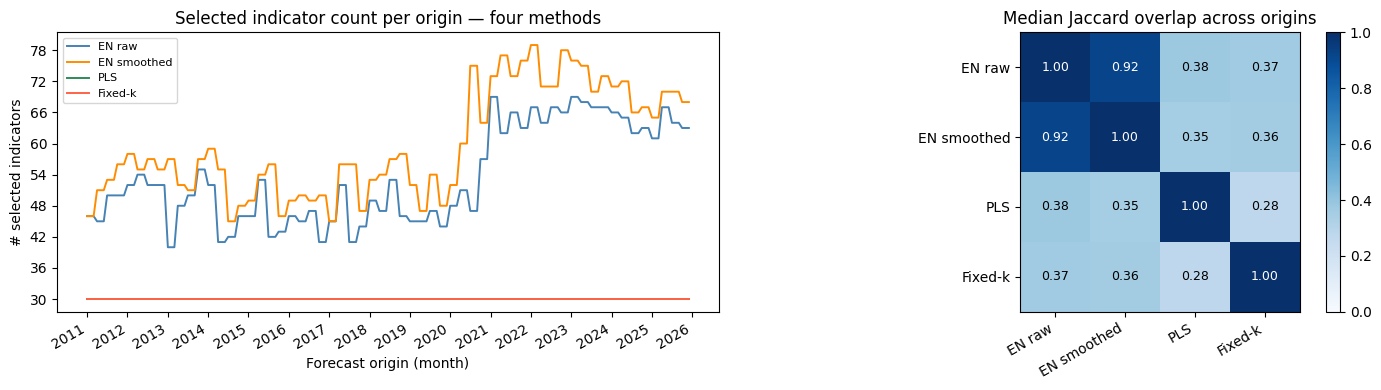


Selected count statistics per origin:
       EN raw  EN smoothed    PLS  Fixed-k
count   180.0        180.0  180.0    180.0
mean     53.4         59.6   30.0     30.0
std       9.2         10.2    0.0      0.0
min      40.0         45.0   30.0     30.0
25%      46.0         51.8   30.0     30.0
50%      51.5         56.5   30.0     30.0
75%      63.0         70.0   30.0     30.0
max      69.0         79.0   30.0     30.0


In [9]:
import matplotlib.dates as mdates
matrices = {
    'EN raw':     en_matrix,
    'EN smoothed': en_smoothed,
    'PLS':        pls_matrix,
    'block-balanced (k=20)':    fixedk_matrix,
}
# — Panel 1: selection counts over time
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
_x = pd.to_datetime(en_matrix.index)
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato']
for (label, mat), color in zip(matrices.items(), colors):
    n_sel = mat.reindex(en_matrix.index, fill_value=0).sum(axis=1)
    ax.plot(_x, n_sel.values, label=label, lw=1.4, color=color)
ax.set_xlabel('Forecast origin (month)')
ax.set_ylabel('# selected indicators')
ax.set_title('Selected indicator count per origin — four methods')
ax.legend(fontsize=8)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
# — Panel 2: pairwise Jaccard heatmap (median across origins)
ax = axes[1]
method_names = list(matrices.keys())
n_methods = len(method_names)
jaccard_grid = np.zeros((n_methods, n_methods))
for i, (_, mi) in enumerate(matrices.items()):
    for j, (_, mj) in enumerate(matrices.items()):
        intersection = (mi.astype(bool) & mj.astype(bool)).sum(axis=1)
        union = (mi.astype(bool) | mj.astype(bool)).sum(axis=1)
        jaccard_grid[i, j] = (intersection / union.replace(0, np.nan)).median()
im = ax.imshow(jaccard_grid, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(n_methods)); ax.set_xticklabels(method_names, rotation=30, ha='right')
ax.set_yticks(range(n_methods)); ax.set_yticklabels(method_names)
ax.set_title('Median Jaccard overlap across origins')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
for i in range(n_methods):
    for j in range(n_methods):
        ax.text(j, i, f'{jaccard_grid[i, j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if jaccard_grid[i, j] > 0.6 else 'black')
plt.tight_layout()
plt.show()
# Summary table
summary = pd.DataFrame({
    label: mat.sum(axis=1).describe().round(1)
    for label, mat in matrices.items()
})
print('\nSelected count statistics per origin:')
print(summary)

### 4b. Interpreting the Cross-Method Comparison

#### Selection Count Dynamics

The time series of active predictors per origin reveals each method's **adaptive versus fixed-dimension behaviour**:

- **Elastic Net (raw):** Variable selection count driven by cross-validation over an expanding window. Increases typically reflect (i) growing training sample providing stable coefficient identification for more predictors, (ii) periods of higher GDP volatility where more series pass the regularisation threshold, or (iii) structural breaks requiring different predictor coverage.

- **Elastic Net (smoothed):** Count changes relative to raw EN quantify the net effect of the persistence filter. If smoothed count exceeds raw, historically persistent series that temporarily dropped out are being reincorporated; the reverse indicates trimming of transiently selected series.

- **PLS and Fixed-k:** Constant dimension (30 series) by construction. Comparing their overlap with variable-dimension EN addresses whether data-driven shrinkage converges to a similar effective dimension, or whether EN systematically selects larger/smaller active sets.

**Economic interpretation:** Selection count is the *effective information set size* at each vintage. In nowcasting practice, larger is not necessarily better: Bai & Ng (2008) and Boivin & Ng (2006) demonstrate that including too many weakly informative or noise-dominated series can degrade factor and forecast quality. The comparison across methods informs the choice of input dimension for the DFM in Part II.

#### Jaccard Similarity Matrix

The Jaccard coefficient J(*A*, *B*) = |*A* ∩ *B*| / |*A* ∪ *B*| measures pairwise set overlap at each origin. The heatmap displays the **median Jaccard across all 180 monthly origins** for each method pair.

**Interpretation thresholds** (conventional, not absolute):
- **J ≥ 0.6:** High agreement. Both methods identify a largely overlapping predictor set, suggesting algorithmic robustness. Suitable for a single DFM input pool.
- **0.4 ≤ J < 0.6:** Moderate overlap. Methods share a core but differ on peripheral selections. Motivates sensitivity analysis with separate DFM runs per method.
- **J < 0.4:** Low agreement. Methods stress different information (e.g., sparsity-based EN vs. supervised-covariance PLS). Warrants (i) examination of sectoral/category divergence, (ii) union or intersection input designs, or (iii) forecast combination.

**Practical use:**
1. **Robustness reporting:** Cite median Jaccard as a quantitative measure of cross-method agreement in the thesis results section.
2. **DFM input design:** High Jaccard → single input pool likely sufficient. Low Jaccard → run multiple DFM specifications (one per method) and report sensitivity of nowcast accuracy.
3. **Economic interpretation:** Low EN-PLS Jaccard may reflect PLS selecting multiple correlated indicators (industrial orders + production + confidence) where EN picks one representative, consistent with their respective regularisation philosophies.

#### Selection Frequency as a Stability Metric

The **selection frequency** of series *j* is the proportion of the 180 forecast origins at which it was included in the active set. This is a *method-specific* measure of **persistent predictive relevance**, not structural causality. High-frequency series are repeatedly judged informative for GDP growth conditional on:
- The expanding-window training design  
- The regularisation/selection criterion (EN penalty, PLS-VIP, IC)  
- The rest of the available predictor panel  

**Note on PLS:** The current pipeline stores selected series IDs per origin but not the full VIP score trajectories. Selection frequency is the appropriate cross-method-comparable stability measure, aligned with how applied nowcasting studies discuss "leading indicators" (e.g., Stock & Watson, 2002; Bańbura & Rünstler, 2011).

**Reporting:** Report top-N series by mean selection frequency across methods (Section 4c plots) as candidates for economic discussion. Emphasise that frequency reflects *conditional forecasting importance* in this specific GDP nowcasting design, not general economic significance.

**References:**
- Bai, J., & Ng, S. (2008). Forecasting economic time series using targeted predictors. *Journal of Econometrics*, 146(2), 304–317.
- Bańbura, M., & Rünstler, G. (2011). A look into the factor model black box: Publication lags and the role of hard and soft data in forecasting GDP. *International Journal of Forecasting*, 27(2), 333–346.
- Boivin, J., & Ng, S. (2006). Are more data always better for factor analysis? *Journal of Econometrics*, 132(1), 169–194.
- Stock, J. H., & Watson, M. W. (2002). Forecasting using principal components from a large number of predictors. *Journal of the American Statistical Association*, 97(460), 1167–1179.


In [ ]:
# — Economic diagnostics: persistent indicators, categories, cross-method agreement
from textwrap import shorten
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
_meta_path = _tp.DATA_DICT_ENRICHED_CSV
_data_dict = pd.read_csv(_meta_path, usecols=['id', 'name', 'category'])
_data_dict = _data_dict.set_index('id')
def _selection_rates(mat: pd.DataFrame) -> pd.Series:
    """Share of forecast origins in which each column is selected (1/non-zero)."""
    return mat.astype(float).sum(axis=0) / len(mat)
# --- 1) Top series by average selection rate across the four methods (persistence)
_rate_frames = {label: _selection_rates(mat) for label, mat in matrices.items()}
rate_table = pd.DataFrame(_rate_frames)
rate_table['mean_across_methods'] = rate_table.mean(axis=1)
rate_table = rate_table.join(_data_dict[['name', 'category']], how='left')
rate_table['category'] = rate_table['category'].fillna('Unknown')
TOP_K = 25
top_ids = rate_table['mean_across_methods'].sort_values(ascending=False).head(TOP_K).index
plot_df = rate_table.loc[top_ids].copy()
# Slightly wider y-labels (~two extra words vs previous 72-char wrap)
plot_df['label'] = [
    shorten(f"{rid}: {plot_df.loc[rid, 'name']}", width=92, placeholder='…')
    for rid in plot_df.index
]
# PUBLICATION-READY OKABE-ITO PALETTE
METHOD_COLORS = ['#0072B2', '#56B4E9', '#B2C997', '#CC79A7'] 
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 2, width_ratios=[1.12, 1], height_ratios=[1, 1.05], hspace=0.34, wspace=0.28)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1]) # Corrected from ax_d
ax_c = fig.add_subplot(gs[1, :]) # Panel C now aligns with ax_c
# Panel A — horizontal bar: mean selection rate (cross-method persistence)
y_pos = np.arange(len(plot_df))
# Using a muted steel blue for the bars to look professional and distinct from method colors
ax_a.barh(y_pos, plot_df['mean_across_methods'].values, color='#4A6984', alpha=0.95, height=0.72)
ax_a.set_yticks(y_pos)
ax_a.set_yticklabels(plot_df['label'], fontsize=7)
ax_a.invert_yaxis()
ax_a.set_xlabel('Mean selection frequency across methods')
ax_a.set_title(f'Top {TOP_K} indicators by persistent inclusion (all four methods)')
ax_a.set_xlim(0, 1.05)
# Added a contrasting rust color for the median line to make it pop
ax_a.axvline(rate_table['mean_across_methods'].median(), color='#C85200', ls='--', lw=1.2,
             label='Median over all series')
ax_a.legend(loc='lower right', fontsize=7)
ax_a.grid(axis='x', linestyle='--', alpha=0.35)
ax_a.set_axisbelow(True)
# Panel B (full width) — category composition as % of each method's total selections
cat_rows = []
for mlabel, mat in matrices.items():
    counts = mat.astype(int).sum(axis=0)
    tmp = counts.rename('n_sel').to_frame().join(_data_dict['category'], how='left')
    tmp['category'] = tmp['category'].fillna('Unknown')
    g = tmp.groupby('category', observed=False)['n_sel'].sum().sort_values(ascending=False)
    cat_rows.append(g.rename(mlabel))
cat_wide = pd.concat(cat_rows, axis=1).fillna(0)
_top_cats = cat_wide.sum(axis=1).sort_values(ascending=False).head(12).index
cat_plot_counts = cat_wide.loc[_top_cats]
# Each bar = share of that method's overall selection mass (all categories, all origins)
_method_totals = cat_wide.sum(axis=0).replace(0, np.nan)
cat_plot = cat_plot_counts.div(_method_totals, axis=1).mul(100).fillna(0)
x = np.arange(len(cat_plot.index))
width = 0.19
n_m = len(cat_plot.columns)
offsets = np.linspace(-(n_m - 1) / 2, (n_m - 1) / 2, n_m) * width * 1.15
for i, col in enumerate(cat_plot.columns):
    ax_c.bar(
        x + offsets[i],
        cat_plot[col].values,
        width,
        label=col,
        color=METHOD_COLORS[i % len(METHOD_COLORS)],
        edgecolor='white',
        linewidth=0.75,
        alpha=0.95,
        zorder=2,
    )
ax_c.set_xticks(x)
ax_c.set_xticklabels(cat_plot.index, rotation=32, ha='right', fontsize=9)
ax_c.set_ylabel("Share of method's selections (%)")
ax_c.set_title(
    'Macroeconomic composition of the selected set\n'
    "(each bar: % of that method's total selections in that category; top-12 categories by overall mass)"
)
ax_c.legend(fontsize=8, ncol=4, frameon=True, loc='upper right')
ax_c.set_axisbelow(True)
ax_c.grid(axis='y', linestyle='--', alpha=0.38)
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
# Panel C — core set size: indicators selected by at least 3 of 4 methods
_bool_stack = np.stack([mat.astype(bool).values for mat in matrices.values()], axis=0)
votes = _bool_stack.sum(axis=0)
core_per_origin = (votes >= 3).sum(axis=1)
orig_dt = pd.to_datetime(en_matrix.index.astype(str), errors='coerce')
# Changed to a deep slate/indigo for a sophisticated finish
line_color = '#2C3E50' 
if orig_dt.notna().all():
    ax_b.plot(orig_dt, core_per_origin, color=line_color, lw=1.75)
    ax_b.fill_between(orig_dt, core_per_origin, alpha=0.15, color=line_color)
    ax_b.set_xlabel('Forecast origin')
else:
    ax_b.plot(core_per_origin.values, color=line_color, lw=1.75)
    ax_b.set_xlabel('Monthly forecast origin (index)')
ax_b.set_ylabel('Count: in ≥3 methods')
ax_b.set_title('Series selected by at least three of four methods')
ax_b.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax_b.grid(axis='y', linestyle='--', alpha=0.35)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
# Table for thesis text (full series names)
print('\nTop-20 by mean selection frequency (with category and full name):')
_disp = rate_table.sort_values('mean_across_methods', ascending=False).head(20)
_disp = _disp[['mean_across_methods', 'category', 'name']]
print(_disp.round(3).to_string())


### 4c. Reading the Economic Diagnostics

The preceding visualisations provide three complementary perspectives on the selected predictor sets: (i) individual-series persistence, (ii) macroeconomic composition, and (iii) cross-method consensus over time.

#### Panel A: Top Persistent Indicators by Mean Selection Frequency

**Construction:** Each series' selection frequency is computed separately for each of the four methods (fraction of 180 origins at which it was selected), then averaged across methods. The top 25 series by this cross-method mean frequency are displayed.

**Economic interpretation:**  
Series ranking highly are *persistently judged informative for German GDP growth* by multiple algorithms under the expanding-window real-time design. This cross-method persistence suggests these indicators carry robust predictive content, though several caveats apply:

1. **Correlation structure:** In macro panels, highly correlated series (e.g., multiple industrial production indices, related survey indicators) often "compete" for selection. One representative from a correlated cluster may rank high while others rank low, despite similar GDP correlation. Selection frequency reflects *algorithmic preference* given the full panel context, not standalone GDP informativeness.

2. **Not structural causality:** High selection frequency indicates *conditional forecasting relevance* in this nowcasting setting. It does not imply that the series *causes* GDP movements or that interventions on the indicator would affect GDP (a distinction central to Granger causality and structural VAR literature; see Lütkepohl, 2005).

3. **Use in thesis narrative:** Top-ranking series are natural candidates for economic discussion in the main text. For example, one can contrast:
   - **Hard data** (industrial production, trade volumes) vs. **soft data** (business confidence, survey expectations)  
   - **Domestic indicators** (German-specific series) vs. **international/trade** (Eurozone aggregates, commodity prices)  
   - **Forward-looking** (new orders, permits) vs. **coincident** (current output, sales)

   The median line on the plot indicates the distribution centre; series far above it are outliers in persistence.

#### Panel B: Macroeconomic Category Composition (Sectoral Coverage)

**Construction:** Each bar shows the share of that method's total selections (aggregated over all origins and all 585 series) that falls into one of the top-12 categories by overall selection mass. The y-axis is percentage of each method's selections, not percentage of all 585 series.

**Reading the chart:**  
- **Within a category (comparing bar heights):** Which selection method emphasises this category most? For example, if PLS shows a taller bar for "Surveys & Sentiment" than EN, PLS systematically selects more survey indicators.
  
- **Across categories for one method (comparing one colour):** Which sectors dominate that method's selections? A well-balanced nowcasting input should cover multiple information sources (production, trade, prices, sentiment, financial) rather than concentrating in one domain (Bańbura & Rünstler, 2011).

- **Residual mass:** Percentages within the plotted 12 categories need not sum to 100% for a given method; the difference represents selections from smaller, unlisted categories. If this residual is large, category coverage is highly dispersed.

**Economic interpretation for thesis:**  
Use this panel to argue that the selected predictor set provides **broad macroeconomic coverage** rather than over-representing one sector. If all four methods show similar category profiles, this supports a narrative that the DFM input captures the key dimensions of the German business cycle. Divergent profiles (e.g., EN stressing hard data, PLS stressing surveys) motivate sensitivity checks in Part II and discussion of information complementarity.

**References:** Bańbura & Rünstler (2011) document that survey (soft) data become particularly valuable for nowcasting when hard data are subject to publication lags; category composition plots can support such arguments quantitatively.

#### Panel C: Algorithm-Robust Core Set Size Over Time

**Construction:** At each monthly origin, count the series selected by at least three of the four methods. This is a vote, not a claim that the methods recover one indicator list.

**Economic interpretation:**  
- **A large vote set would mean series-level agreement.** That is not what Part I finds. Category composition is shared (hard activity); membership is not. Part II therefore treats the input sets as competing components rather than averaging them into one list.

- **Declining or volatile core:** Periods where the core set shrinks may align with:
  1. **Structural breaks** (e.g., pandemic onset, energy-price shock) where methods temporarily disagree on which indicators remain relevant.
  2. **Data arrival patterns** where some methods are more responsive to panel composition changes.
  3. **Regime-specific information:** EN may drop indicators with unstable coefficients while PLS retains them if their covariance with GDP remains high.

**Use in thesis:**  
- **Role of the vote set in this repository:** it feeds XGBoost hyperparameter tuning. The headline DFM uses the raw elastic-net matrix; block-balanced and ifoCAST enter as structured comparisons.
- **Sensitivity analysis:** If the core is thin or volatile, justify running separate DFM nowcasts for each method's selections (or union/intersection designs) and comparing forecast accuracy.
- **Structural break discussion:** Overlay core-set dips with known economic events (CEPR recession dates, pandemic, policy interventions) to interpret disagreement episodes.

#### Printed Table: Top-20 Series with Full Metadata

The table below the plots lists the top 20 series by mean selection frequency across methods, including category and full series name. Use this for:
- **Appendix presentation:** Direct inclusion in thesis appendix as "Table X: Most Persistently Selected Indicators"  
- **What to cite:** category mass (turnover, orders, production) and the two always-selected elastic-net series (retail turnover excluding vehicles; accommodation and food-services turnover). Headline ifo balances are not a cross-method core; four of the nineteen ifoCAST indicators — all forward-looking survey balances — are never selected by the elastic net at any origin.

**References:**
- Abberger, K., Birnbrich, M., & Seiler, C. (2014). The German business cycle and the Ifo Business Climate Index. *Journal of Business Cycle Research*, 10(2), 179–195.
- Bańbura, M., & Rünstler, G. (2011). A look into the factor model black box: Publication lags and the role of hard and soft data in forecasting GDP. *International Journal of Forecasting*, 27(2), 333–346.
- Lütkepohl, H. (2005). *New Introduction to Multiple Time Series Analysis*. Springer.
